In [1]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pandas as pd
import numpy as np

#import copula functions
from pr_copula.main_copula_regression_conditional import fit_copula_cregression,predict_copula_cregression,predictive_resample_cregression,check_convergence_pr_cregression

from causal_mp import mp_causal_density, mp_causal_density_diagnostic
from causal_mp_iv import mp_density_iv

## Motivating Example

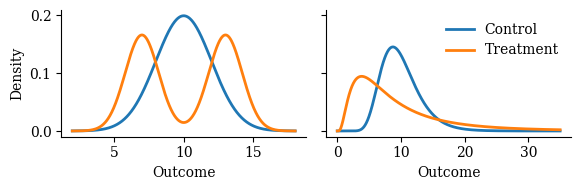

In [2]:
from scipy.stats import norm, lognorm

# --- Parameters ---
mu = 10          # The common mean
sigma_0 = 2.0    # SD for control
x = np.linspace(mu - 8, mu + 8, 1000) # Slightly wider range for the tail

# 1. Polarization Parameters
delta = 3
sigma_sub = 1.2

# 2. Lottery Parameters
s = 0.7  # Shape parameter (skewness)
# For a Lognormal with scale=1, mean is exp(s^2 / 2). 
# To shift the mean to 'mu', we set loc = mu - exp(s^2 / 2)
loc_shift = mu - np.exp(s**2 / 2)

# --- Calculate PDFs ---

# Shared Control PDF
pdf_y0 = norm.pdf(x, mu, sigma_0)

# Left: Polarization Treatment (Mixture)
pdf_y1_pol = 0.5 * norm.pdf(x, mu - delta, sigma_sub) + 0.5 * norm.pdf(x, mu + delta, sigma_sub)

# Right: Lottery Treatment (Shifted Log-Normal)
target_mean = 10
x_b = np.linspace(0, 35, 1000) # Longer tail for lottery

# Control: Lower skewness
s0 = 0.3
mu0 = np.log(target_mean) - (s0**2 / 2)
pdf_y0_b = lognorm.pdf(x_b, s0, scale=np.exp(mu0))
# Treatment: Higher skewness
s1 = 0.8
mu1 = np.log(target_mean) - (s1**2 / 2)
pdf_y1_b = lognorm.pdf(x_b, s1, scale=np.exp(mu1))


# --- Plotting ---
plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        10,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.linewidth":   0.8,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 2), sharey=True)

# Panel A: Polarization
ax1.plot(x, pdf_y0, label='Control', lw=2)
ax1.plot(x, pdf_y1_pol, label='Treatment', lw=2)
ax1.set_xlabel("Outcome")
ax1.set_ylabel("Density")


# Panel B: Lottery
ax2.plot(x_b, pdf_y0_b, label='Control', lw=2)
ax2.plot(x_b, pdf_y1_b, label='Treatment', lw=2)
ax2.set_xlabel("Outcome")
ax2.legend(frameon=False)

plt.tight_layout()
plt.savefig("Figures/Motivating_Example.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Unconfounded with multiple covariates (Simulation 1, J = 2)

Based on Simulation 1 with strong confounding (J = 2) from Xu et al. (2022, [arXiv:2211.01591](https://arxiv.org/abs/2211.01591)). Each subject has 5 covariates $W_j \sim U(-2, 2)$, of which the first two are confounders that drive the propensity score $X \mid W \sim \mathrm{Bern}(\mathrm{expit}(2(W_1 + W_2)))$. The control potential outcome $Y(0)$ is right-skewed and shared across two scenarios that differ only in the treated outcome $Y(1)$:

- **Scenario 1 (simple):** $Y(1)$ is unimodal and skewed to the opposite side of the control, so the two potential-outcome distributions are broadly similar.
- **Scenario 2 (paper):** $Y(1)$ is a bimodal mixture of normals.

On a single realisation ($n = 100$) we compare three variants of our estimator — **S-Learner + Bayesian bootstrap**, **S-Learner + logistic** treatment model, and **T-Learner + Bayesian bootstrap** — showing both the marginal counterfactual densities and the conditional interventional densities at $W = (1/2, \dots, 1/2)$, against the ground truth.

In [2]:
from scipy.stats import norm

# Simulation 1 (J = 2), based on Xu et al. (2022), arXiv:2211.01591.
# Two scenarios share the (right-skewed) control outcome Y(0) but differ in Y(1):
#   scenario 1 (simple): Y(1) is unimodal and skewed to the opposite side of the control,
#                        so the two potential-outcome distributions are broadly similar;
#   scenario 2 (paper) : Y(1) is a bimodal mixture of normals.

def _expit(a):
    return 1.0 / (1.0 + np.exp(-a))

def _Z(w, k):
    # Z_k = expit(0.8 * sum_j w_j + 0.1 * sum_j |w_j|^k), per covariate row
    w = np.asarray(w, dtype=float)
    axis = w.ndim - 1
    return _expit(0.8 * w.sum(axis=axis) + 0.1 * (np.abs(w) ** k).sum(axis=axis))

def _eps_pdf(e):
    # right-skewed control error: eps ~ 0.75 N+(0, 0.9^2) + 0.25 N-(0, 0.3^2)
    pos = 0.75 * 2.0 * norm.pdf(e, 0.0, 0.9) * (e >= 0)
    neg = 0.25 * 2.0 * norm.pdf(e, 0.0, 0.3) * (e < 0)
    return pos + neg

def _sample_eps0(n):
    # right-skewed (control) half-normal mixture
    pos = np.random.uniform(size=n) < 0.75
    return np.where(pos, np.abs(np.random.normal(0.0, 0.9, n)), -np.abs(np.random.normal(0.0, 0.3, n)))

def _sample_eps1(n):
    # mirror of eps0 -> left-skewed (scenario-1 treated error)
    pos = np.random.uniform(size=n) < 0.75
    return np.where(pos, -np.abs(np.random.normal(0.0, 0.9, n)), np.abs(np.random.normal(0.0, 0.3, n)))

def generate_data_sim1(n, scenario=2, J=2):
    # draws from the global NumPy RNG -- set np.random.seed(...) once to control it
    X = np.random.uniform(-2, 2, size=(n, 5))
    ps = _expit((4.0 / J) * X[:, :J].sum(axis=1))
    Tr = (np.random.uniform(size=n) < ps).astype(int)
    Z1, Z2 = _Z(X, 1), _Z(X, 2)

    # Y(0): -2.3 + Z1 + Z1^2 + eps0  (right-skewed; shared by both scenarios)
    y0 = -2.3 + Z1 + Z1 ** 2 + _sample_eps0(n)

    if scenario == 1:
        # Y(1): unimodal, skewed to the opposite side, mild location shift -> similar to Y(0)
        y1 = -1.3 + Z2 + Z2 ** 2 + _sample_eps1(n)
    else:
        # Y(1): bimodal mixture of normals with means depending on Z2 (paper)
        comp1 = np.random.uniform(size=n) < 0.7
        y1 = np.where(comp1, np.random.normal(-2.5 + 5 * Z2, 0.35), np.random.normal(2.5 - 5 * Z2, 0.35))

    Y_obs = np.where(Tr == 1, y1, y0)
    return Y_obs, Tr, X

# True *conditional* interventional densities p(y | X=t, W=w).  w may be a single covariate
# row (-> (n_y,)) or a batch of rows (-> (n_rows, n_y)).  Y(0) is shared across scenarios.
def true_y0_cond_density_sim1(y_grid, w):
    m = np.atleast_1d(-2.3 + _Z(w, 1) + _Z(w, 1) ** 2)
    dens = _eps_pdf(np.asarray(y_grid)[None, :] - m[:, None])
    return dens[0] if np.ndim(_Z(w, 1)) == 0 else dens

def true_y1_cond_density_sim1(y_grid, w, scenario=2):
    y = np.asarray(y_grid)[None, :]
    if scenario == 1:
        m = np.atleast_1d(-1.3 + _Z(w, 2) + _Z(w, 2) ** 2)
        dens = _eps_pdf(m[:, None] - y)            # mirrored -> left-skewed
    else:
        z2 = np.atleast_1d(_Z(w, 2))
        dens = (0.7 * norm.pdf(y, (-2.5 + 5 * z2)[:, None], 0.35)
                + 0.3 * norm.pdf(y, (2.5 - 5 * z2)[:, None], 0.35))
    return dens[0] if np.ndim(_Z(w, 2)) == 0 else dens

# True marginal counterfactual densities: average the conditional over X ~ U(-2,2)^5.
# A large, fixed Monte Carlo sample from a private RNG keeps this deterministic ground
# truth reproducible and independent of the global RNG used for data generation.
def true_y0_density_sim1(y_grid, M=200000):
    X = np.random.default_rng(1).uniform(-2, 2, size=(M, 5))
    return true_y0_cond_density_sim1(y_grid, X).mean(axis=0)

def true_y1_density_sim1(y_grid, scenario=2, M=200000):
    X = np.random.default_rng(2).uniform(-2, 2, size=(M, 5))
    return true_y1_cond_density_sim1(y_grid, X, scenario).mean(axis=0)


In [3]:
# single realisation, both scenarios
n = 100
SEED = 42
T_fwd, B_post = 2000, 100

results = {}
for sc in (1, 2):
    # reset the seed so both scenarios share covariates, treatment and Y(0) (only Y(1) differs)
    np.random.seed(SEED)
    y_s, x_s, w_s = generate_data_sim1(n, scenario=sc, J=2)
    grid = np.linspace(y_s.min() - 0.5, y_s.max() + 0.5, 50)

    methods = [
        ("S-Learner + BB",       mp_causal_density_diagnostic(y_s, x_s, w_s, grid, B_post, T_fwd),                      "#1f77b4"),
        ("S-Learner + Logistic", mp_causal_density_diagnostic(y_s, x_s, w_s, grid, B_post, T_fwd, x_update="logistic"), "#ff7f0e"),
        ("T-Learner + BB",       mp_causal_density_diagnostic(y_s, x_s, w_s, grid, B_post, T_fwd, learner="t"),         "#2ca02c"),
    ]

    results[sc] = {
        "grid": grid,
        "methods": methods,
        "true": {
            "marg": {"x_1": true_y1_density_sim1(grid, scenario=sc),
                     "x_0": true_y0_density_sim1(grid)},
        },
    }

Compiling...
Compilation time: 2.404s
Optimizing...
Optimization time: 0.397s
Fitting...
Fit time: 0.006s
Optimised rho:  0.42914224
Optimised rho_x:  [0.8880335  0.28713462 0.33448243 0.48962083 0.34237465 0.39345506]
Prequential log-likelihood:  -1.122745394706726
Predicting...
Prediction time: 1.32s
Diagnostic resampling...
Compiling...
Compilation time: 0.03s
Optimizing...
Optimization time: 0.344s
Fitting...
Fit time: 0.009s
Optimised rho:  0.42914224
Optimised rho_x:  [0.8880335  0.28713462 0.33448243 0.48962083 0.34237465 0.39345506]
Prequential log-likelihood:  -1.122745394706726
Predicting...
Prediction time: 0.53s
Diagnostic resampling...
Compiling...
Compilation time: 2.269s
Optimizing...
Optimization time: 0.162s
Fitting...
Fit time: 0.001s
Optimised rho for x=0:  0.6386494
Optimised rho_x for x=0:  [1.3258554e-07 9.8583777e-04 1.6504719e-03 7.8387005e-04 2.8807709e-01]
Prequential log-likelihood for x=0:  -1.0507391691207886
Predicting...
Prediction time: 0.624s
Diagnostic

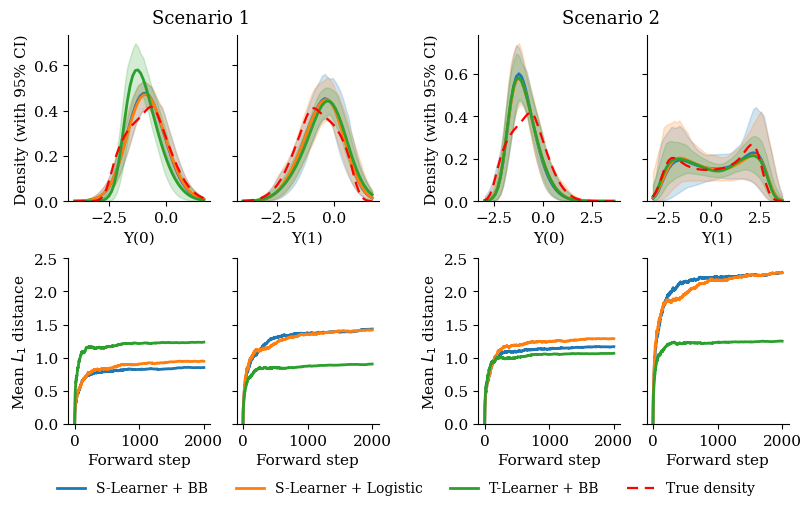

In [10]:
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.linewidth":   0.8,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
})

ALPHA = 0.2
DASH = (0, (5, 3))

cols = [("x_0", "Y(0)"), ("x_1", "Y(1)")]

fig = plt.figure(figsize=(8, 5), constrained_layout=True)
subfigs = fig.subfigures(1, 2, wspace=0.05)

l1_axes = []

for sf, sc in zip(subfigs, (1, 2)):
    sf.suptitle(f"Scenario {sc}", fontsize=13)
    axs = sf.subplots(2, 2, sharex='row', sharey='row')

    R = results[sc]
    grid = R["grid"]

    # Top row: marginal densities with credible bands
    for c, (xkey, lab) in enumerate(cols):
        ax = axs[0, c]
        for name, res, color in R["methods"]:
            d = res[xkey]
            ax.fill_between(grid, d['low'], d['high'], color=color, alpha=ALPHA)
            ax.plot(grid, d['mean'], color=color, linewidth=2)
        ax.plot(grid, R["true"]["marg"][xkey], color="red", linewidth=1.6, linestyle=DASH)
        ax.set_ylim(bottom=0)
        ax.set_xlabel(lab, fontsize=11)
    axs[0, 0].set_ylabel("Density (with 95% CI)", fontsize=11)

    # Bottom row: mean L1 stability trajectories
    for c, (xkey, lab) in enumerate(cols):
        ax = axs[1, c]
        xi = int(xkey.split("_")[1])
        for name, res, color in R["methods"]:
            l1 = res["l1_trajectory"][:, :, xi]  # (B, T+1)
            steps = np.arange(l1.shape[1])
            ax.plot(steps, l1.mean(axis=0), color=color, linewidth=2)
        ax.set_ylim(bottom=0)
        ax.set_xlabel("Forward step", fontsize=11)
    axs[1, 0].set_ylabel(r"Mean $L_1$ distance", fontsize=11)
    l1_axes.extend([axs[1, 0], axs[1, 1]])

# unify y-limits across all L1 plots
#ymax = max(ax.get_ylim()[1] for ax in l1_axes)
for ax in l1_axes:
    ax.set_ylim(0, 2.5)

# shared legend below the whole figure
legend_handles = [Line2D([0], [0], color=color, linewidth=2, label=name)
                  for name, _, color in results[1]["methods"]]
legend_handles.append(Line2D([0], [0], color="red", linewidth=1.6, linestyle=DASH, label="True density"))
fig.legend(handles=legend_handles, loc="outside lower center", ncol=4, frameon=False, fontsize=10)

fig.savefig('Figures/Simulation_Illustration.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# ── Coverage experiment: repeat over many simulated datasets, for both scenarios ─────────
# For each scenario and replicate we draw a fresh dataset, fit all three estimators on a
# coarse fixed grid, and record (i) whether the true density is contained in the pointwise
# 95% credible interval and (ii) the interval length, at every grid point.
import io, contextlib

n_datasets = 200                            # number of replicated datasets
n = 100                                     # sample size per dataset
y_grid_exp = np.linspace(-3.5, 3.5, 20)     # coarse, fixed evaluation grid
T_fwd_exp, B_post_exp = 500, 100
NOMINAL = 0.95
scenarios = (1, 2)

variants = {
    "S-Learner + BB":       dict(),
    "S-Learner + Logistic": dict(x_update="logistic"),
    "T-Learner + BB":       dict(learner="t"),
}

n_grid = len(y_grid_exp)
coverage = {sc: {m: {k: np.zeros(n_grid) for k in ("x_0", "x_1")} for m in variants} for sc in scenarios}
mean_len = {sc: {m: {k: np.zeros(n_grid) for k in ("x_0", "x_1")} for m in variants} for sc in scenarios}

for sc in scenarios:
    # true densities on the evaluation grid (Y(0) shared; Y(1) scenario-specific)
    true_exp = {"x_1": true_y1_density_sim1(y_grid_exp, scenario=sc),
                "x_0": true_y0_density_sim1(y_grid_exp)}

    covered = {m: {k: np.zeros(n_grid) for k in ("x_0", "x_1")} for m in variants}
    length  = {m: {k: np.zeros(n_grid) for k in ("x_0", "x_1")} for m in variants}

    np.random.seed(0)   # same replicate datasets across scenarios (only Y(1) differs)
    for s in range(n_datasets):
        y_d, x_d, w_d = generate_data_sim1(n, scenario=sc, J=2)
        for m, kw in variants.items():
            with contextlib.redirect_stdout(io.StringIO()):   # silence per-fit prints
                res = mp_causal_density(y_d, x_d, w_d, y_grid_exp, B_post_exp, T_fwd_exp, seed=s, **kw)
            for k in ("x_0", "x_1"):
                d = res[k]
                covered[m][k] += (true_exp[k] >= d["low"]) & (true_exp[k] <= d["high"])
                length[m][k]  += d["high"] - d["low"]
        if (s + 1) % 10 == 0:
            print(f"scenario {sc}: completed {s + 1}/{n_datasets} datasets")

    for m in variants:
        for k in ("x_0", "x_1"):
            coverage[sc][m][k] = covered[m][k] / n_datasets
            mean_len[sc][m][k] = length[m][k]  / n_datasets

# tidy per-grid-point summary and persist to disk
rows = []
for sc in scenarios:
    for m in variants:
        for k, lab in [("x_1", "Y(1)"), ("x_0", "Y(0)")]:
            for gi, g in enumerate(y_grid_exp):
                rows.append({"scenario": sc, "method": m, "outcome": lab, "y": round(float(g), 2),
                             "coverage": coverage[sc][m][k][gi],
                             "mean_length": mean_len[sc][m][k][gi]})
coverage_df = pd.DataFrame(rows)
coverage_df.to_csv("Figures/Simulation_coverage_results.csv", index=False)

# overall average across grid points, per scenario / method / outcome
summary = (coverage_df.groupby(["scenario", "method", "outcome"])[["coverage", "mean_length"]]
           .mean().round(3))
print("\nAverage over grid points:")
print(summary)


scenario 1: completed 10/200 datasets
scenario 1: completed 20/200 datasets
scenario 1: completed 30/200 datasets
scenario 1: completed 40/200 datasets
scenario 1: completed 50/200 datasets
scenario 1: completed 60/200 datasets
scenario 1: completed 70/200 datasets
scenario 1: completed 80/200 datasets
scenario 1: completed 90/200 datasets
scenario 1: completed 100/200 datasets
scenario 1: completed 110/200 datasets
scenario 1: completed 120/200 datasets
scenario 1: completed 130/200 datasets
scenario 1: completed 140/200 datasets
scenario 1: completed 150/200 datasets
scenario 1: completed 160/200 datasets
scenario 1: completed 170/200 datasets
scenario 1: completed 180/200 datasets
scenario 1: completed 190/200 datasets
scenario 1: completed 200/200 datasets
scenario 2: completed 10/200 datasets
scenario 2: completed 20/200 datasets
scenario 2: completed 30/200 datasets
scenario 2: completed 40/200 datasets
scenario 2: completed 50/200 datasets
scenario 2: completed 60/200 datasets
s

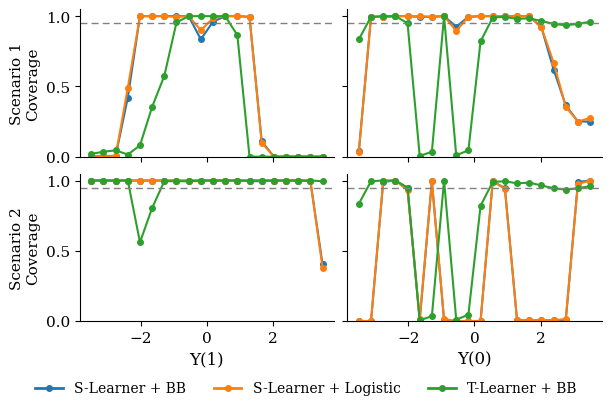

In [27]:
from matplotlib.lines import Line2D as Line2D_cov

plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.linewidth":   0.8,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
})

colors = {
    "S-Learner + BB":       "#1f77b4",
    "S-Learner + Logistic": "#ff7f0e",
    "T-Learner + BB":       "#2ca02c",
}

fig, axes = plt.subplots(2, 2, figsize=(6, 4), sharex=True, sharey=True, constrained_layout=True)

for r, sc in enumerate(scenarios):
    for c, (k, lab) in enumerate([("x_1", r"Y(1)"), ("x_0", r"Y(0)")]):
        ax = axes[r, c]
        for m in variants:
            ax.plot(y_grid_exp, coverage[sc][m][k], marker="o", ms=4, color=colors[m])
        ax.axhline(NOMINAL, color="grey", linestyle=(0, (5, 3)), linewidth=1)
        ax.set_ylim(0, 1.05)
        if r == len(scenarios) - 1:
            ax.set_xlabel(lab, fontsize=12)
    axes[r, 0].set_ylabel(f"Scenario {sc}\nCoverage", fontsize=11)

legend_handles = [Line2D_cov([0], [0], color=c, linewidth=2, marker="o", ms=4, label=m)
                  for m, c in colors.items()]
#legend_handles.append(Line2D_cov([0], [0], color="grey", linewidth=1, linestyle=(0, (5, 3)), label="Nominal (0.95)"))
fig.legend(handles=legend_handles, loc="outside lower center", ncol=4, frameon=False, fontsize=10)

plt.savefig('Figures/Simulation_Results.pdf', dpi=300, bbox_inches='tight')
plt.show()

## IV with continuous treatment

A nonlinear instance of the general IV model:

$$Y = f(X) + \varepsilon, \qquad X = \pi Z + \eta, \qquad Z, \eta \sim \mathrm{N}(0, 1),$$

with $f(x) = \alpha + 2\tanh(1.5 x)$ and $\varepsilon = c_1 \eta + c_2 (\eta^2 - 1) + \nu$, where $\nu \sim \mathrm{N}(0, \sigma_\nu^2)$.

The control function $\mathbb{E}[\varepsilon \mid \eta] = c_1 \eta + c_2 (\eta^2 - 1)$ is nonlinear, so $p(y(x))$ is right-skewed and differs from $p(y \mid X = x)$ in shape rather than only in location. Neither density is available in closed form, but both are one-dimensional integrals over $\eta$ that we evaluate by quadrature.

In [39]:
from scipy.stats import norm

# Z, eta ~ N(0, 1);  X = pi Z + eta;  Y = f(X) + eps
# eps = c1 eta + c2 (eta^2 - 1) + nu  ->  nonlinear control function E[eps | eta]
# c1 drives the mean gap between p(y(x)) and p(y | X = x), c2 the skew; raising either
# shrinks s_nu, so c1^2 + 2 c2^2 < 1 is the ceiling.
IV_ALPHA = 0.0
IV_PI    = 1.0
IV_C1    = 0.7
IV_C2    = 0.35
IV_SNU2  = 1.0 - IV_C1 ** 2 - 2 * IV_C2 ** 2     # chosen so that Var(eps) = 1
IV_SNU   = np.sqrt(IV_SNU2)


def iv_f(x):
    return IV_ALPHA + 2.0 * np.tanh(1.5 * np.asarray(x, dtype=float))


def generate_iv_dgp(n: int = 1000, seed: int = 42):
    rng = np.random.default_rng(seed)
    Z   = rng.standard_normal(n)
    eta = rng.standard_normal(n)
    nu  = rng.normal(0.0, IV_SNU, n)
    eps = IV_C1 * eta + IV_C2 * (eta ** 2 - 1.0) + nu
    X   = IV_PI * Z + eta
    return iv_f(X) + eps, X, Z


# Y | x, eta is Gaussian and both eta laws below are Gaussian, so each density is a
# one-dimensional integral over eta.
_ETA_QUAD = np.linspace(-8.0, 8.0, 4001)


def _iv_density(y_grid, x, eta_mean, eta_sd):
    w = norm.pdf(_ETA_QUAD, eta_mean, eta_sd)
    w = w / np.trapezoid(w, _ETA_QUAD)
    m = iv_f(x) + IV_C1 * _ETA_QUAD + IV_C2 * (_ETA_QUAD ** 2 - 1.0)
    k = norm.pdf(np.asarray(y_grid, dtype=float)[:, None], m[None, :], IV_SNU)
    return np.trapezoid(k * w[None, :], _ETA_QUAD, axis=1)


def true_iv_interventional(y_grid, x):
    """p(y(x)): eta ~ N(0, 1)."""
    return _iv_density(y_grid, x, 0.0, 1.0)


def true_iv_observational(y_grid, x):
    """p(y | X = x): eta | X = x ~ N(x / (pi^2 + 1), 1 - 1 / (pi^2 + 1))."""
    v = 1.0 - 1.0 / (IV_PI ** 2 + 1.0)
    return _iv_density(y_grid, x, x / (IV_PI ** 2 + 1.0), np.sqrt(v))


In [42]:
# simulate data and fit martingale posteriors
y, x, z = generate_iv_dgp(n=500, seed=42)
T_fwd, B_post = 2000, 100

x_val = -1.0

# standardise y for the copula fit; densities are mapped back to the original scale below
mean_y, sd_y = np.mean(y), np.std(y)
y_std = (y - mean_y) / sd_y

# mp_density_iv evaluates p(y | x, eta_i) at each of the n empirical eta_i, so memory grows
# as B_post * len(y_grid) * n * T_fwd -- raise any of these too far and it exhausts RAM.
y_grid = np.linspace(-5.0, 1.0, 50)
y_grid_std = (y_grid - mean_y) / sd_y

# IV control-function estimate of p(y(x))
res_int = mp_density_iv(y_std, x, z, x_val, y_grid_std, B_post, T_fwd)['x_0']

# observational comparison p(y | X = x); w is constant, so nothing is conditioned on
res_obs = mp_causal_density(y_std, x, np.ones(len(y)), y_grid_std, B_post, T_fwd, x_vals=x_val)['x_0']


First-stage estimation:
  Estimated coefficients: [[-0.04477899]
 [ 0.99070283]]
  Mean residual: -0.000000
  Std residual: 1.017318
Compiling...
Compilation time: 0.602s
Optimizing...
Optimization time: 3.655s
Fitting...
Fit time: 0.126s

Conditional density fit:
  Optimised rho: 0.6397130489349365
  Optimised rho_x: [0.8315488  0.81532556]
  Prequential log-likelihood: -0.269441157579422
Predicting...
Prediction time: 3.054s
Predictive resampling (IV-modified)...
Predictive resampling time: 50.305s
Compiling...
Compilation time: 0.763s
Optimizing...
Optimization time: 4.486s
Fitting...
Fit time: 0.14s
Optimised rho:  0.5414782
Optimised rho_x:  [0.6928569  0.74076396]
Prequential log-likelihood:  -0.43804770708084106
Predicting...
Prediction time: 0.064s
Predictive resampling...
Predictive resampling time: 0.606s


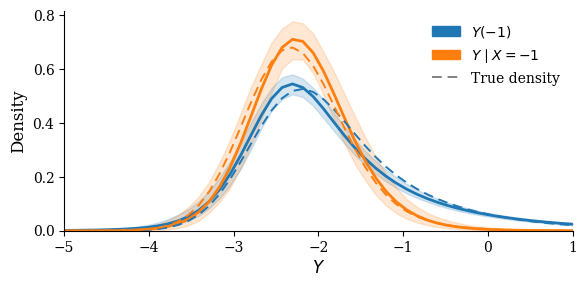

In [44]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D


# ── style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.linewidth":   0.8,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
})

BLUE   = "#1f77b4"
ORANGE = "#ff7f0e"
ALPHA  = 0.18
DASH   = (0, (5, 3))

fig, ax = plt.subplots(figsize=(6, 3))

# ── estimated densities + credible bands (undoing the y standardisation) ───
ax.fill_between(y_grid, res_int['low'] / sd_y, res_int['high'] / sd_y, color=BLUE,   alpha=ALPHA)
ax.fill_between(y_grid, res_obs['low'] / sd_y, res_obs['high'] / sd_y, color=ORANGE, alpha=ALPHA)

ax.plot(y_grid, res_int['mean'] / sd_y, color=BLUE,   linewidth=2)
ax.plot(y_grid, res_obs['mean'] / sd_y, color=ORANGE, linewidth=2)

# ── true densities (dashed) ────────────────────────────────────────────────
ax.plot(y_grid, true_iv_interventional(y_grid, x_val), color=BLUE,   linewidth=1.4, linestyle=DASH)
ax.plot(y_grid, true_iv_observational(y_grid, x_val),  color=ORANGE, linewidth=1.4, linestyle=DASH)

# ── legend: estimated curves only + single "true" entry ───────────────────
legend_handles = [
    mpatches.Patch(color=BLUE,   label=rf"$Y({x_val:g})$"),
    mpatches.Patch(color=ORANGE, label=rf"$Y \mid X = {x_val:g}$"),
    Line2D([0], [0], color="grey", linewidth=1.4,
           linestyle=DASH, label="True density"),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=10)

# ── axes labels & layout ───────────────────────────────────────────────────
ax.set_xlabel(r"$Y$",    fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_xlim(y_grid[0], y_grid[-1])
ax.set_ylim(bottom=0)
ax.tick_params(labelsize=10)

fig.tight_layout()
plt.savefig('Figures/IV_Simulation.pdf', dpi=300, bbox_inches='tight')
plt.show()
